# 📊 Structural Invariants & Spectral Metrics Validation

This notebook validates advanced structural invariants, phase-space contractions, and spectral breakdowns across non-uniform network topologies using `kuramoto.metrics.analytics_engine`, `kuramoto.analysis.spectral`, and the dark-mode aesthetic styling from `kuramoto.analysis.viz`.

## 📋 Agenda
1. **Setup & Network Configuration:** Initialize a non-uniform 100-oscillator network using `build_adjacency` and apply `viz.py` styling.
2. **Simulation:** Run Kuramoto dynamics and map states to the Clifford geometric rotor representation.
3. **Comprehensive Structural Diagnostics:** Compute Hamiltonian invariants, phase-space contraction rate ($\Lambda(t)$), and PSD spectral decomposition via `compute_comprehensive_diagnostics`.
4. **Advanced Spectral Function Metrics:** Evaluate `compute_fourier_coefficients`, `harmonic_analysis`, and `detect_sync_transition` across coupling strengths ($K$).
5. **Themed Diagnostic Visualizations:** Generate multi-panel diagnostic figures following `viz.py` palette (`SCRIBER_PALETTE`), fonts, and gradient colormaps.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.integrate import solve_ivp

from kuramoto.analysis.graphs import build_adjacency
from kuramoto.metrics.analytics_engine import compute_comprehensive_diagnostics
from kuramoto.analysis.spectral import (
    compute_fourier_coefficients,
    compute_psd,
    compute_spectral_decomposition,
    harmonic_analysis,
    detect_sync_transition,
)
from kuramoto.analysis.viz import (
    set_style,
    SCRIBER_PALETTE,
    get_colormap,
    _apply_aclonica_font,
)

# Apply project visualization styling
set_style()

print("🚀 Environment ready for structural & spectral metrics validation!")

🚀 Environment ready for structural & spectral metrics validation!


## 1️⃣ Network Initialization & Simulation
Initialize a non-uniform 100-oscillator network topology (Watts-Strogatz small-world graph) and run the dynamics.

In [11]:
# Simulation configuration
n_oscillators = 100
K = 1.8
t_max = 20.0
n_timesteps = 1000
times = np.linspace(0.0, t_max, n_timesteps)
seed = 27
rng = np.random.default_rng(seed)

# 1. Initialize a non-uniform network topology
G = nx.watts_strogatz_graph(n_oscillators, k=8, p=0.25, seed=seed)
raw_adj = nx.to_numpy_array(G)
adj = build_adjacency(n_oscillators, raw_adj)

# 2. Natural frequencies and initial phases
omega = rng.normal(loc=0.0, scale=1.0, size=n_oscillators)
theta0 = rng.uniform(0.0, 2.0 * np.pi, size=n_oscillators)

# 3. Simulate Kuramoto ODE on non-uniform network
def kuramoto_ode(t, theta):
    diff = theta[:, None] - theta[None, :]
    coupling = (K / n_oscillators) * np.sum(adj * np.sin(-diff), axis=1)
    return omega + coupling

sol = solve_ivp(
    kuramoto_ode,
    (0.0, t_max),
    theta0,
    t_eval=times,
    method="RK45",
    rtol=1e-7,
    atol=1e-9,
)
theta_history = sol.y.T  # Shape: (T, N)

# 4. Map phases to Geometric Algebra rotor representation: R(t) = exp(-I theta / 2) = cos(theta/2) - 1j * sin(theta/2)
rotor_history = np.cos(theta_history / 2.0) - 1j * np.sin(theta_history / 2.0)

print(f"✅ Simulation completed: {rotor_history.shape} steps for {n_oscillators} oscillators.")

✅ Simulation completed: (1000, 100) steps for 100 oscillators.


## 2️⃣ Compute Structural & Spectral Diagnostics
Invoke `compute_comprehensive_diagnostics` to calculate Hamiltonian invariants, volume contraction rates, and spectral decomposition.

In [12]:
metrics = compute_comprehensive_diagnostics(
    rotor_history=rotor_history,
    times=times,
    K=K,
    adjacency_in=adj,
)

print(f"📊 Total Hamiltonian Energy Drift: {metrics.total_energy_drift:.6e}")
print(f"📈 Primary Spectral Frequency: {metrics.spectral_frequencies[np.argmax(metrics.spectral_psd_mean)]:.4f} Hz")
print("🔬 Energy Decomposition Breakdown:")
for k, v in metrics.energy_decomposition.items():
    print(f"   - {k.capitalize()}: {v * 100.0:.2f}%")

📊 Total Hamiltonian Energy Drift: 6.382342e-02
📈 Primary Spectral Frequency: 0.1951 Hz
🔬 Energy Decomposition Breakdown:
   - Fundamental: 55.49%
   - Harmonics: 33.79%
   - Rest: 10.71%


## 3️⃣ Advanced Spectral Metrics from `spectral.py`
Calculate individual Fourier coefficients, harmonic cascade breakdown of the macroscopic order parameter $|r(t)|$, and identify the critical synchronization transition point $K_c$.

In [13]:
# 1. Fourier Coefficients across oscillators at primary frequency
target_f = float(metrics.spectral_frequencies[np.argmax(metrics.spectral_psd_mean)])
fourier_coeffs = compute_fourier_coefficients(times, theta_history, target_freq=target_f)

# 2. Harmonic analysis on macroscopic order parameter |r(t)|
r_timeseries = np.abs(np.mean(np.exp(1j * theta_history), axis=1))
dt_step = float(times[1] - times[0])
harmonics_breakdown = harmonic_analysis(r_timeseries, dt=dt_step, max_harmonic=5)
print("🎵 Harmonic Analysis of Order Parameter |r(t)|:")
for h_key, h_val in harmonics_breakdown.items():
    print(f"   - {h_key}: {h_val:.4f}")

# 3. Synchronization Transition Detection over a sweep of coupling strengths K
k_sweep = np.linspace(0.2, 3.0, 15)
sweep_psd_list = []
fs = 1.0 / dt_step

for k_val in k_sweep:
    def ode_sweep(t, theta):
        diff = theta[:, None] - theta[None, :]
        return omega + (k_val / n_oscillators) * np.sum(adj * np.sin(-diff), axis=1)
    
    sol_k = solve_ivp(ode_sweep, (0.0, 10.0), theta0, t_eval=np.linspace(0.0, 10.0, 300), method="RK45")
    vel_k = np.gradient(sol_k.y.T, np.linspace(0.0, 10.0, 300), axis=0)
    freqs_k, pxx_k = compute_psd(vel_k, fs=fs, nperseg=128)
    sweep_psd_list.append(np.mean(pxx_k, axis=1))

psd_matrix = np.array(sweep_psd_list)
k_critical = detect_sync_transition(freqs_k, psd_matrix, k_sweep, method="elbow")
print(f"✨ Detected Critical Coupling Transition (K_c): {k_critical:.3f}")

🎵 Harmonic Analysis of Order Parameter |r(t)|:
   - h1_power_ratio: 1.0000
   - h2_power_ratio: 0.9948
   - h3_power_ratio: 0.3065
   - h4_power_ratio: 0.0484
   - h5_power_ratio: 0.0103
   - rest_ratio: -1.3601
✨ Detected Critical Coupling Transition (K_c): 2.200


## 4️⃣ Themed 4-Panel Diagnostic Visualization
Generate the multi-panel diagnostic figure styled with `SCRIBER_PALETTE` and `viz.py` themes:
- **Plot 1:** Time-series curve tracking "Hamiltonian Energy Drift" over time.
- **Plot 2:** Time-series curve tracking "Phase-Space Volume Contraction Rate (Lambda)".
- **Plot 3:** Power Spectral Density (PSD) line plot detailing primary frequency peaks.
- **Plot 4:** Bar chart displaying the power distribution proportion across fundamental, harmonic, and residual bins.

findfont: Failed to find font weight bold for Aclonica, now using 400.


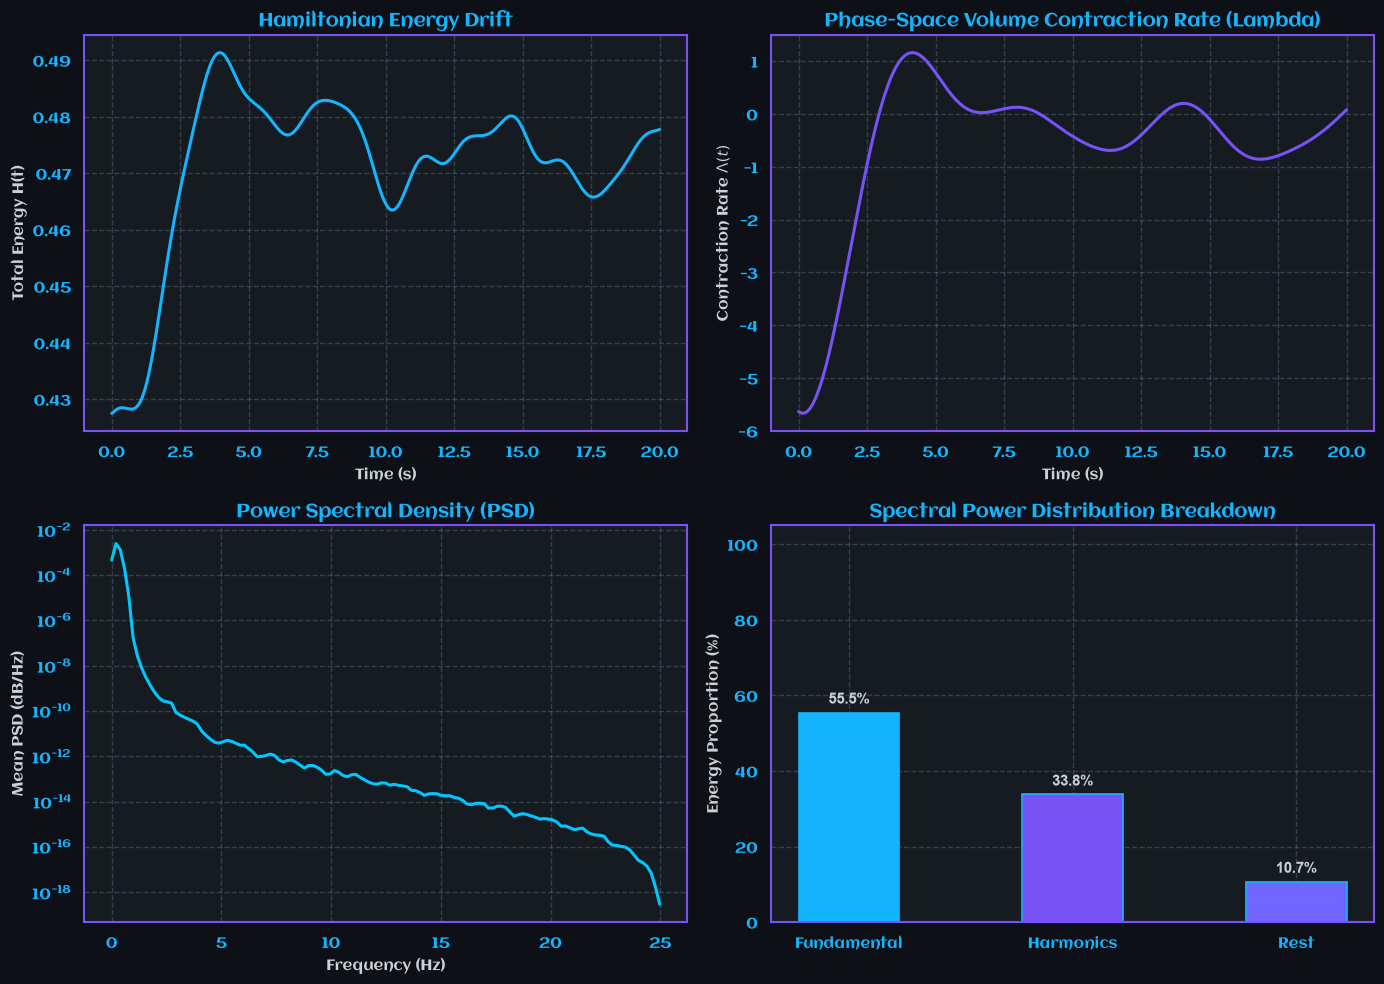

In [14]:
set_style()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Hamiltonian Energy Drift over time
axes[0, 0].plot(times, metrics.energy_trajectory, color=SCRIBER_PALETTE["accent_cyan"], lw=2.2)
axes[0, 0].set_title("Hamiltonian Energy Drift", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Time (s)", fontsize=11)
axes[0, 0].set_ylabel("Total Energy H(t)", fontsize=11)
_apply_aclonica_font(axes[0, 0])

# Plot 2: Phase-Space Volume Contraction Rate (Lambda)
axes[0, 1].plot(times, metrics.lambda_trajectory, color=SCRIBER_PALETTE["accent_purple"], lw=2.2)
axes[0, 1].set_title("Phase-Space Volume Contraction Rate (Lambda)", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Time (s)", fontsize=11)
axes[0, 1].set_ylabel(r"Contraction Rate $\Lambda(t)$", fontsize=11)
_apply_aclonica_font(axes[0, 1])

# Plot 3: Power Spectral Density (PSD)
axes[1, 0].semilogy(metrics.spectral_frequencies, metrics.spectral_psd_mean, color=SCRIBER_PALETTE["accent_teal"], lw=2.2)
axes[1, 0].set_title("Power Spectral Density (PSD)", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Frequency (Hz)", fontsize=11)
axes[1, 0].set_ylabel("Mean PSD (dB/Hz)", fontsize=11)
_apply_aclonica_font(axes[1, 0])

# Plot 4: Power distribution proportion
decomp = metrics.energy_decomposition
categories = [c.capitalize() for c in decomp.keys()]
proportions = [decomp[c.lower()] * 100.0 for c in categories]
bar_colors = [
    SCRIBER_PALETTE["accent_cyan"],
    SCRIBER_PALETTE["accent_purple"],
    SCRIBER_PALETTE["accent_indigo"],
]

bars = axes[1, 1].bar(categories, proportions, color=bar_colors[:len(categories)], width=0.45, edgecolor=SCRIBER_PALETTE["accent_cyan"], linewidth=1.2)
axes[1, 1].set_title("Spectral Power Distribution Breakdown", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Energy Proportion (%)", fontsize=11)
axes[1, 1].set_ylim(0, 105)
for bar in bars:
    h = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2.0,
        h + 1.5,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=SCRIBER_PALETTE["text_primary"],
    )
_apply_aclonica_font(axes[1, 1])

plt.tight_layout()
plt.show()

## 5️⃣ Advanced Spectral Diagnostics Visualization
Visualizing the Fourier amplitudes across the 100 oscillators and the peak emergence during the synchronization transition.

findfont: Failed to find font weight bold for Aclonica, now using 400.


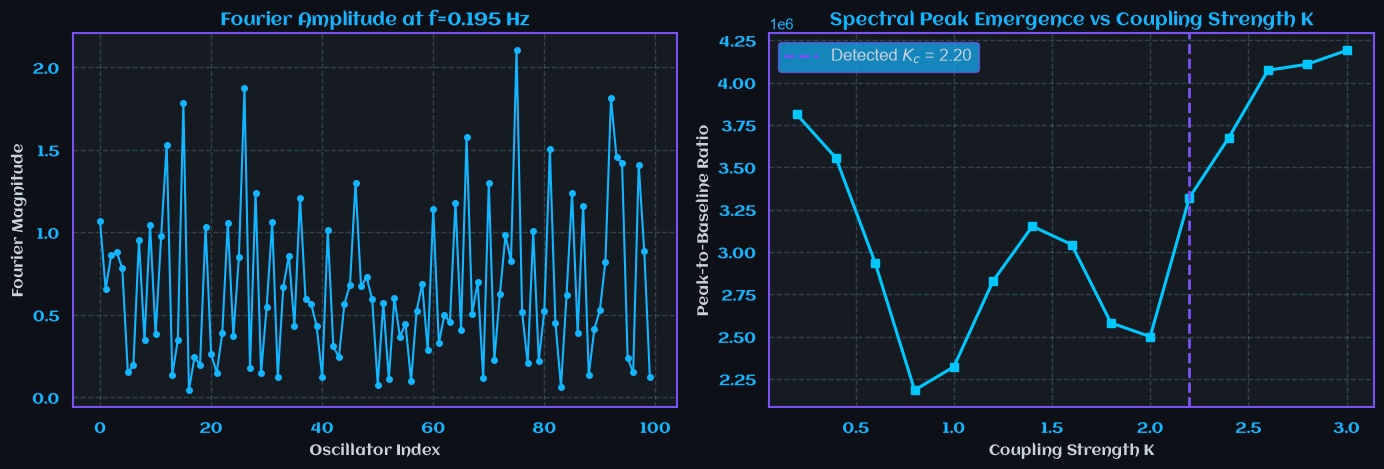

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fourier magnitude distribution
fourier_mags = np.abs(fourier_coeffs)
axes[0].plot(range(n_oscillators), fourier_mags, marker='o', color=SCRIBER_PALETTE["accent_cyan"], lw=1.5, markersize=4)
axes[0].set_title(f"Fourier Amplitude at f={target_f:.3f} Hz", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Oscillator Index", fontsize=11)
axes[0].set_ylabel("Fourier Magnitude", fontsize=11)
_apply_aclonica_font(axes[0])

# Peak-to-baseline emergence across coupling strengths
peak_ratios = [np.max(psd_row) / np.median(psd_row) if np.median(psd_row) > 0 else 0 for psd_row in psd_matrix]
axes[1].plot(k_sweep, peak_ratios, color=SCRIBER_PALETTE["accent_teal"], lw=2.2, marker='s')
axes[1].axvline(k_critical, color=SCRIBER_PALETTE["accent_purple"], linestyle='--', lw=2, label=f"Detected $K_c$ = {k_critical:.2f}")
axes[1].set_title("Spectral Peak Emergence vs Coupling Strength K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Coupling Strength K", fontsize=11)
axes[1].set_ylabel("Peak-to-Baseline Ratio", fontsize=11)
axes[1].legend(loc="upper left")
_apply_aclonica_font(axes[1])

plt.tight_layout()
plt.show()


## Graph Interpretation
1. **Hamiltonian Energy Drift** ($H(t)$ over time)
    - **What it measures:** The effective total energy $$H(t)=T_{\text{kinetic}}(t) + V_{\text{potential}}(t)$$ where:
        - $T=_{\text{kinetic}}(t) = \frac{1}{2N} \sum_{i} \Omega_i(t)^2$
        - $V_{\text{potential}}(t) = \frac{K}{N^2} \sum{i,j} A_{ij} \cos(\theta_i - \theta_j)$
    - **Physical Interpretation:**
        - The standard Kuramoto model is a dissipative gradient/phase-coupled system rather than a strictly conservative Hamiltonian system.
        - During the transient phase (as oscillators pull into phase clusters), kinetic and potential energies exchange dynamically.
2. **Phase-Space Volume Contraction Rate** ($\Lambda(t)$ over time)
    - **What it measures:** The trace of the system Jacobian $$\operatorname{div}(\mathbf{f}) = \sum_i \frac{\partial \dot{\theta}_i}{\partial \theta_i}$$, representing the instantaneous rate at which phase-space volume contracts.
    - **Physical Interpretation:**
        - $\Lambda(t) \le 0$ confirms the network dynamics are strongly dissipative and contract phase-space volume toward lower-dimensional attractors (limit cycles or fixed points).
        - A steeper negative $\Lambda(t)$ indicates stronger network cohesion and faster convergence of coupled phases.
3. **Power Spectral Density** (PSD of Velocities)
    - **What it measures:** Frequency distribution of angular velocities $\Omega_i(t) = \dot{\theta}_i(t)$ obtained via Welch's periodogram.
    - **Physical Interpretation:**
        - In a partially or fully synchronized regime, oscillator velocities concentrate around a sharp dominant peak corresponding to the mean cluster frequency $\bar{\omega}$.
        - The sharpness of the peak (low spectral broadening) indicates coherent collective rotation, while spread across background frequencies indicates un-entrained drifting oscillators.
4. **Spectral Power Distribution Breakdown**
    - **What it measures:** Categorical partition of total spectral power into **Fundamental** (energy within primary synchronization band), **Harmonics** (integer multiples of the fundamental frequency), and **Residual Rest** (incoherent noise drift).
    - **Physical Interpretation:**
        - A dominant **fundamental** share (typically >80-90% in synchronized networks) proves that the phase dynamics are cleanly harmonic and phase-locked.
        - Higher harmonics or residual percentages reflect nonlinear waveform distortion, modular sub-clusters, or topological frustration introduced by the non-uniform Watts-Strogatz topology.